## Elo Rating method

This is the Elo method.  The example is taken from "Who's #1" by Langville and Meyer and the results match.  Note, the data includes the entire 2009 NFL season, including all playoff games.  

Reference: https://www.gautamnarula.com/rating/

In [3]:
import math 
  
# Function to calculate the Probability 
def Probability(rating1, rating2): 
  
    return 1.0 * 1.0 / (1 + 1.0 * math.pow(10, 1.0 * (rating1 - rating2) / 400)) 
  
# Function to calculate Elo rating 
# K is a constant. 
# Player A wins over Player B.  
# tie = true if tie, false otherwise
def EloRating(Ra, Rb, K, tie): 
    
    # To calculate the Winning 
    # Probability of Player B 
    Pb = Probability(Ra, Rb) 
  
    # To calculate the Winning 
    # Probability of Player A 
    Pa = Probability(Rb, Ra) 
  
    # Updating the Elo Ratings 
    if tie:
       Ra = Ra + K * (1/2 - Pa) 
       Rb = Rb + K * (1/2 - Pb) 
    else:        
       Ra = Ra + K * (1 - Pa) 
       Rb = Rb + K * (0 - Pb) 
    
    return Ra, Rb

In [5]:
gameFilename = '24games.txt'
teamFilename = '24teams.txt'

k = 20

### Load the team names into an array

In [8]:
import pandas as pd

teamNames = pd.read_csv(teamFilename, header = None)
numTeams = len(teamNames)

### Load the games

In [11]:
# columns of games are:
#	column 0 = days since 1/1/0000
#	column 1 = date in YYYYMMDD format
#	column 2 = team1 index
#	column 3 = team1 homefield (1 = home, -1 = away, 0 = neutral)
#	column 4 = team1 score
#	column 5 = team2 index
#	column 6 = team2 homefield (1 = home, -1 = away, 0 = neutral)
#	column 7 = team2 score
games = pd.read_csv(gameFilename, header = None)
numGames = len(games)

### Create Elo ratings and calculate predictability

In [14]:
import numpy as np

K = 136

eloRatings = np.zeros(numTeams)
numberCorrectPredictions=0

for i in range(numGames):
    team1ID = games.loc[i, 2] - 1 # subtracting 1 since python indexes at 0
    team1Score = games.loc[i, 4]
    team2ID = games.loc[i, 5] - 1 # subtracting 1 since python indexes at 0
    team2Score = games.loc[i, 7]

    # Check if prediction correct
    if team1Score > team2Score and eloRatings[team1ID] > eloRatings[team2ID]:
        numberCorrectPredictions += 1
    elif team2Score > team1Score and eloRatings[team2ID] > eloRatings[team1ID]:
        numberCorrectPredictions += 1
    elif team1Score == team2Score and eloRatings[team1ID] == eloRatings[team2ID]:
        numberCorrectPredictions += 1
    
    # Update ratings 
    if team1Score > team2Score:
        team1Rating, team2Rating = EloRating(eloRatings[team1ID], eloRatings[team2ID], K, False)
    elif team1Score < team2Score:
        team2Rating, team1Rating = EloRating(eloRatings[team2ID], eloRatings[team1ID], K, False)
    else:  
        team1Rating, team2Rating = EloRating(eloRatings[team1ID], eloRatings[team2ID], K, True)
        
    eloRatings[team1ID] = team1Rating
    eloRatings[team2ID] = team2Rating

In [16]:
print(numberCorrectPredictions/numGames*100)

87.35632183908046


### Sort and print the ranking of teams

In [19]:
iSort = np.argsort(-eloRatings)

print('\n\n************** ELO Rating Method **************\n')
print('===========================')
print('Rank   Rating      Team   ')
print('===========================')
for i in range(k):
    print(f'{i+1:4d}   {eloRatings[iSort[i]]:.5f}  {teamNames.loc[iSort[i],1]}')

print('')   # extra carriage return

print(f'Predictability: {numberCorrectPredictions/numGames*100:.2f}%') 



************** ELO Rating Method **************

Rank   Rating      Team   
   1   716.71733   3
   2   681.92084   10
   3   668.63707   6
   4   654.88293   9
   5   652.62496   11
   6   651.51613   15
   7   609.64417   14
   8   608.63211   2
   9   588.11060   5
  10   511.83474   13
  11   510.24025   12
  12   501.73344   8
  13   455.26741   7
  14   239.52664   1
  15   176.77964   4
  16   61.77773   Аманжолов Амирлан
  17   61.45266   Даутов Жан
  18   52.54196   Юркевич Мирон
  19   52.14303   Мурат Тимур
  20   28.50748   Роговский Владимир

Predictability: 87.36%


In [21]:
ProblemFile = open("Problem ranking ELO", "w")
for i in range(15):
    index = np.where(iSort == i)[0][0]
    ProblemFile.write('%3i,%3i, %f\n' %(i+1,index+1, eloRatings[iSort[index]]))
ProblemFile.close()

In [30]:
#teamNames - all teams. column 0 - index, column 1 - player. rows 0-14 - problems
studNames=teamNames.iloc[15:,1] #array with students only(ranked by points)
#r - ratings by indexes
studRating=eloRatings[15:]#rating of students
pointFilename='24points.txt' #points
points=pd.read_csv(pointFilename, header=None)
studPoints=points.iloc[:,16]
studNames=studNames.reset_index(drop=True)

=== Correlation Between Olympiad Ranking and Method A ===
Spearman Rank Correlation: 0.235
Kendall's Tau: 0.146



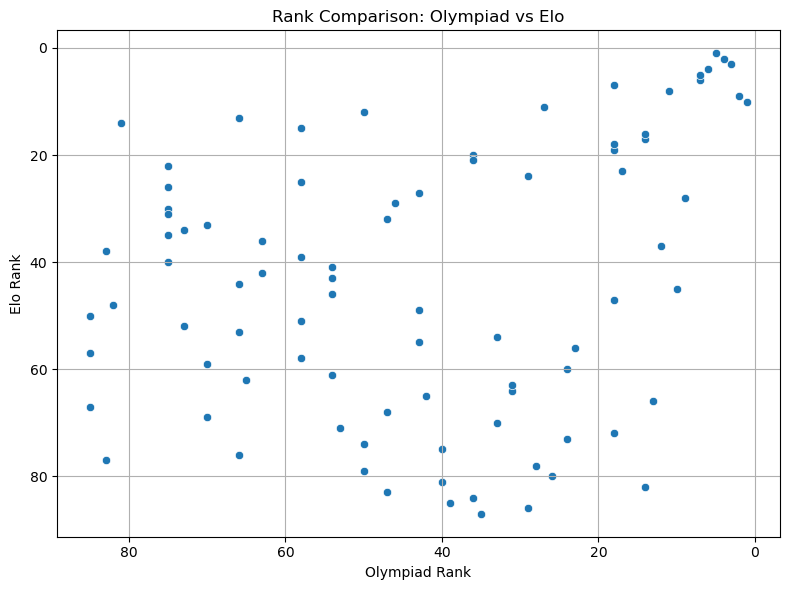

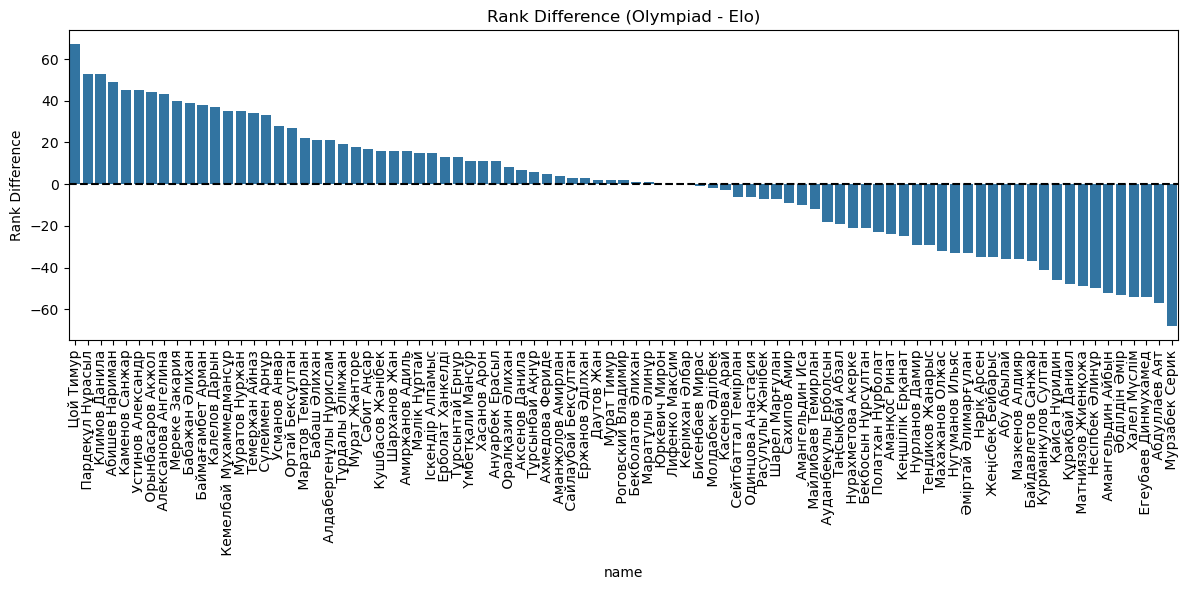

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau

# ---- 1. Your Data as Arrays ----
names = studNames  # Add all 87 names here
pointSum = studPoints                  # Replace with actual point scores
methodA = pd.Series(eloRatings[15:]).reset_index(drop=True)      # Replace with your Method A ratings
# ---- 2. Create DataFrame ----
data = pd.DataFrame({
    'name': names,
    'pointSum': pointSum,
    'methodA': methodA
})


# ---- 3. Compute Rankings ----
data['rank_score'] = data['pointSum'].rank(ascending=False, method='min').astype(int)
data['rank_methodA'] = data['methodA'].rank(ascending=False, method='min').astype(int)
data['rank_diff'] = data['rank_score'] - data['rank_methodA']

# ---- 4. Correlation Analysis ----
spearman_corr, _ = spearmanr(data['rank_score'], data['rank_methodA'])
kendall_corr, _ = kendalltau(data['rank_score'], data['rank_methodA'])

print("=== Correlation Between Olympiad Ranking and Method A ===")
print(f"Spearman Rank Correlation: {spearman_corr:.3f}")
print(f"Kendall's Tau: {kendall_corr:.3f}\n")

# ---- 5. Scatter Plot ----
plt.figure(figsize=(8, 6))
sns.scatterplot(x='rank_score', y='rank_methodA', data=data)
plt.title("Rank Comparison: Olympiad vs Elo")
plt.xlabel("Olympiad Rank")
plt.ylabel("Elo Rank")
plt.grid(True)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---- 6. Rank Difference Bar Plot ----
plt.figure(figsize=(12, 6))
sns.barplot(x='name', y='rank_diff', data=data.sort_values('rank_diff', ascending=False))
plt.xticks(rotation=90)
plt.title("Rank Difference (Olympiad - Elo)")
plt.ylabel("Rank Difference")
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

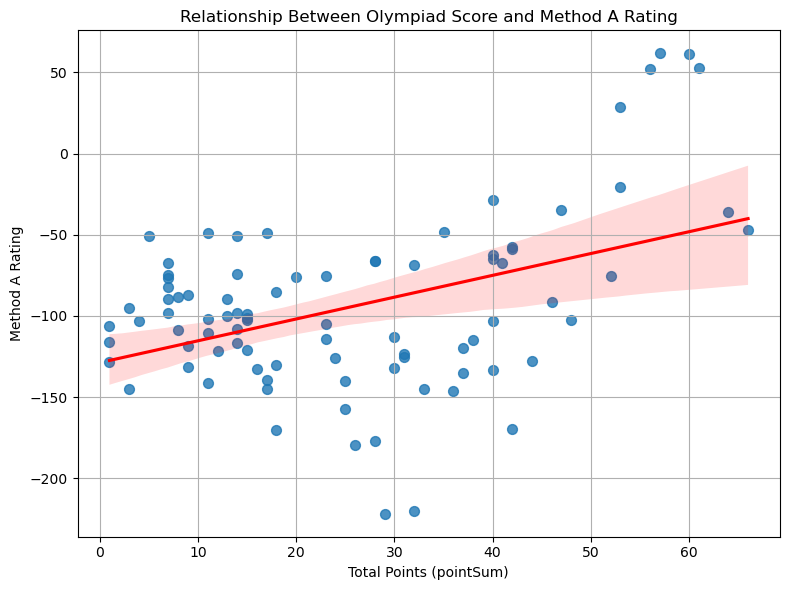

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.regplot(x='pointSum', y='methodA', data=data, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title("Relationship Between Olympiad Score and Method A Rating")
plt.xlabel("Total Points (pointSum)")
plt.ylabel("Method A Rating")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Reshape inputs for sklearn
X = data['pointSum'].values.reshape(-1, 1)
y = data['methodA'].values

# Fit linear model
model = LinearRegression()
model.fit(X, y)
predicted = model.predict(X)

# Calculate residuals
data['residual'] = y - predicted

# Define outliers: residuals greater than 2 standard deviations
threshold = 2 * np.std(data['residual'])
outliers = data[abs(data['residual']) > threshold]

print(f"Number of outliers: {len(outliers)}")
print(outliers[['name', 'pointSum', 'methodA', 'residual']])


Number of outliers: 7
                  name  pointSum     methodA    residual
2        Юркевич Мирон        61   52.541958   99.312683
3           Даутов Жан        60   61.452659  109.568038
4    Аманжолов Амирлан        57   61.777726  113.927068
5          Мурат Тимур        56   52.143031  105.637027
13      Мурзабек Серик        42 -169.557896  -97.238743
28       Абдуллаев Аят        32 -220.448169 -134.682475
34   Амангельдин Айбын        29 -221.870913 -132.071257
